---
title: "🧪 Calibration Analysis of Neural Network Logits with Inferno"
subtitle: "Calibration curves for Effusion and Atelectasis"
author: "Maksim Ohvrill"
date: "5/1/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: R
---


This notebook investigates how well neural network (CNN) outputs align with true outcome probabilities, using Inferno.  
Calibration performance is assessed for two clinical conditions: Effusion and Atelectasis.

In [1]:
# -------------------------------
# Setup
# -------------------------------

# Set working directory one level up
setwd("..")
library(inferno)

# Load reusable utilities
source("RScripts/reusableUtils.R")

# Define general output directory
output_dir <- "data/plots"
if (!dir.exists(output_dir)) {
  dir.create(output_dir)
}

# Define model and data paths
learnt_dir <- "data/inferno/combinedML50"
setup <- load_metadata_testdata(learnt_dir)
metadata <- setup$metadata
test_data <- setup$testdata


## Conditional Probability of Lung Conditions vs Age

We estimate the conditional probability of two lung conditions — **Effusion** and **Atelectasis** — as a function of **Age**.

Specifically, we compute:
- $P(\text{Effusion} = 1 \mid \text{Age})$
- $P(\text{Atelectasis} = 1 \mid \text{Age})$

These probabilities are plotted:
- Solid line for Effusion
- Dashed line for Atelectasis
- 89% variability intervals included to represent model uncertainty

### Interpretation

The plots show how the likelihood of each condition evolves with age


Registered doParallelSNOW with 15 workers

Closing connections to cores.

Registered doParallelSNOW with 15 workers

Closing connections to cores.


pdf 
  2

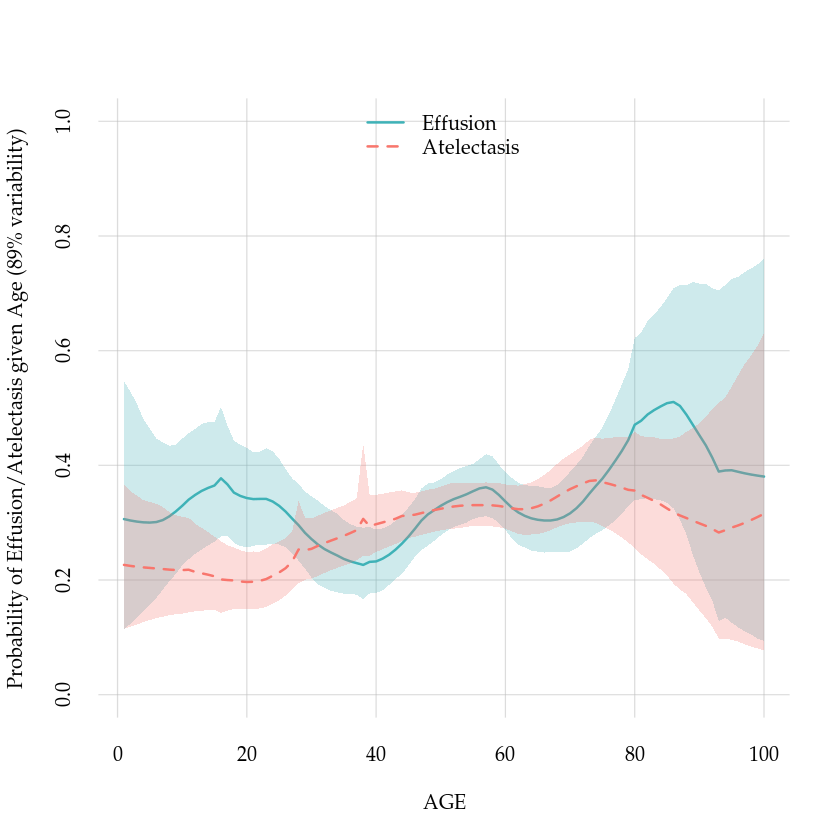

In [3]:
# -------------------------------
# Conditional Probability Curves vs Age
# -------------------------------

# Define input grids
x_age <- data.frame(AGE = 1:100)
y_eff <- data.frame(LABEL_EFFUSION = 1)
y_ale <- data.frame(LABEL_ATELECTASIS = 1)

# Infer probabilities
condpr_eff <- Pr(Y = y_eff, X = x_age, learnt = learnt_dir, parallel = parallel, quantiles = c(0.055, 0.945))
condpr_ale <- Pr(Y = y_ale, X = x_age, learnt = learnt_dir, parallel = parallel, quantiles = c(0.055, 0.945))

# Define plotting function
plot_lung_condition_vs_age <- function() {
  par(family = "Palatino")
  plot(condpr_eff, ylim = 0:1, col = "#3fb2b7", lty = 1, lwd = 2,
       legend = FALSE, ylab = "Probability of Effusion/Atelectasis given Age (89% variability)")
  plot(condpr_ale, ylim = 0:1, col = "#f8766d", lty = 2, lwd = 2,
       legend = FALSE, add = TRUE)
  legend("top", legend = c("Effusion", "Atelectasis"), col = c("#3fb2b7", "#f8766d"), lty = 1:2, lwd = 2, pch = NA, bty = 'n')
}

# Save and display plot
pdf2("lungcondition_vs_age", path = output_dir)
plot_lung_condition_vs_age()
dev.off()
plot_lung_condition_vs_age()


## 📊 Calibration Curves Across Age Groups

This experiment examines how the neural network’s predicted probabilities align with actual outcomes across different age groups. The focus is on predicting pleural effusion ($\text{LABEL\_EFFUSION}$).

### 🎯 Goal of Calibration

A model is well-calibrated if:
$
\text{Observed probability} = \text{Predicted probability}
$
This means, for example, that if the model predicts a 70% chance of effusion, then about 70% of the cases actually have effusion.

### 🧮 Estimating Conditional Probabilities

Because `inferno` does not directly compute probabilities conditional on an interval, conditional probabilities are estimated using:

$
P(Y = 1 \mid \text{logit output},\ a < \text{Age} < b) = \frac{P(Y = 1,\ a < \text{Age} < b \mid \text{logit output})}{P(a < \text{Age} < b \mid \text{logit output})}
$
where:
- $Y$ is the binary target (1 for effusion),
- $a$ and $b$ define the age range,
- The numerator is the joint probability of effusion and age between $a$ and $b$,
- The denominator is the marginal probability of age between $a$ and $b$.

This approach loses variability information but gives a usable estimate for calibration.

### 🛠️ Steps in Calibration

- The calibration is computed for the following non-overlapping age intervals:
    - 0–19 years
    - 20–39 years
    - 40–59 years
    - 60–79 years
    - 80–99 years
- Calculate summed probabilities for each age group.
- Divide joint by marginal probabilities to get conditional estimates.
- Plot estimated probabilities versus the sigmoid output of the neural network.

### 🖼️ Interpretation of the Calibration Plot

- The X-axis shows the neural network’s **sigmoid-transformed logits** ($\text{plogis}(\text{logit output})$).
- The Y-axis shows the **estimated true probability** of effusion for different age groups.
- A **solid red line** represents **perfect calibration**, where the predicted sigmoid output would exactly match the true probability.

If the curves align with the red line, the model outputs are well calibrated.  
Deviation from the red line indicates **bias** or **miscalibration**: the model's raw outputs overestimate or underestimate the true probability, depending on the age group.

pdf 
  2

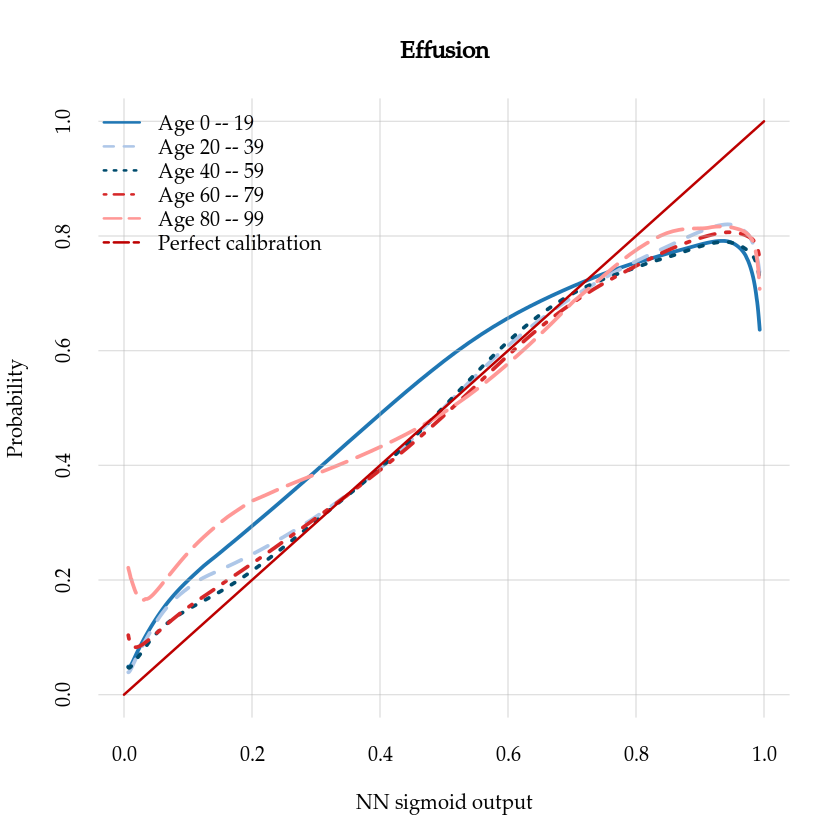

In [ ]:
# -------------------------------
# Calibration Curves Across Age Groups
# -------------------------------

# Define grids for calibration
out_logit <- seq(-5, 5, length.out = 129)

# Effusion probabilities
probs1_eff <- Pr(Y = data.frame(LABEL_EFFUSION = 1, AGE = 0:99),
    X = data.frame(LOGIT_EFFUSION = out_logit),
    learnt = learnt_dir, parallel = parallel,
    quantiles = NULL, nsamples = NULL)

probs2_eff <- Pr(Y = data.frame(AGE = 0:99),
    X = data.frame(LOGIT_EFFUSION = out_logit),
    learnt = learnt_dir, parallel = parallel,
    quantiles = NULL, nsamples = NULL)

# Create grouped calibration curves
cond_probs_eff <- make_calibration_curve(probs1_eff, probs2_eff, group_size = 20)

# Generate darker color palette between two colors
color_palette <- c(
  "#1f77b4",  # Age 0–19
  "#aec7e8",  # Age 20–39
  "#004c6d",  # Age 40–59
  "#d62728",  # Age 60–79
  "#ff9896"   # Age 80–99
)


# Define plotting function
plot_calibration_vs_age <- function() {
  par(family = "Palatino")
  flexiplot(x = plogis(out_logit), y = cond_probs_eff,
            xlab = "NN sigmoid output", ylab = "Probability", main = "Effusion",
            ylim = 0:1, xlim = 0:1,
            col = color_palette, lty = 1:10, lwd = 3)
  flexiplot(x = 0:1, y = 0:1, lty = 1, lwd = 2, col = "#bd0000", add = TRUE)
  legend("topleft",
         legend = c(sapply(seq(0, 80, by = 20), function(minage) paste0("Age ", minage, " -- ", minage + 19)), "Perfect calibration"),
         lty = c(1:10, 1), col = c(color_palette, "#bd0000"), lwd = 2, pch = NA, bty = 'n')
}

# Save and display plot
pdf2("calibration_vs_age", path = output_dir)
plot_calibration_vs_age()
dev.off()
plot_calibration_vs_age()


## 📊 Calibration Curves for Neural Net Outputs vs Inferred Probabilities

For each clinical condition (Effusion, Atelectasis), two calibration plots are generated:

### 🟠 Sigmoid Output Calibration Curve

- **X-axis:** Neural network sigmoid output, computed as $\text{sigmoid}(\text{logit})$.
- **Y-axis:** Bayesian inferred probability, obtained using $\text{Pr}()$.

- The diagonal red line represents perfect calibration where $y = x$.
- Deviation from the red line shows miscalibration, meaning the neural network's predicted confidence does not match true probabilities.

### 🟢 Logit Output Calibration Curve

- **X-axis:** Raw neural network logit scores.
- **Y-axis:** Bayesian inferred probability.

- This view visualizes how raw CNN scores translate to real probabilities, highlighting possible non-linear distortions in the output space.

## ✍️ Threshold at 0.28

- A threshold at $0.28$ is highlighted by a vertical line and a shaded region.
- This threshold maximizes the expected clinical utility for binary classification.
- Interpretation:
  - Patients with CNN sigmoid output above $0.28$ are classified positive under a fixed rule.
  - This fixed threshold assumes perfect calibration across all patients, which is often unrealistic.

- Bayesian recalibration adjusts probabilities patient-by-patient, producing individualized, uncertainty-aware predictions.

## 🎯 Purpose of the Calibration Plots

- **Assess** the agreement between neural network outputs and true inferred probabilities.
- **Visualize** calibration performance separately for Effusion and Atelectasis.
- **Support** the case for Bayesian recalibration rather than relying on simple thresholds.

## 📜 Axis Definitions

- **Sigmoid Calibration Curve:**
  - $ x = \text{sigmoid}(\text{logit}) $
  - $ y = \text{Inferred Probability} $
- **Logit Calibration Curve:**
  - $ x = \text{logit} $
  - $ y = \text{Inferred Probability} $

The ideal calibration follows $ y = x $ (the red diagonal).



Registered doParallelSNOW with 15 workers

Closing connections to cores.

Registered doParallelSNOW with 15 workers

Closing connections to cores.


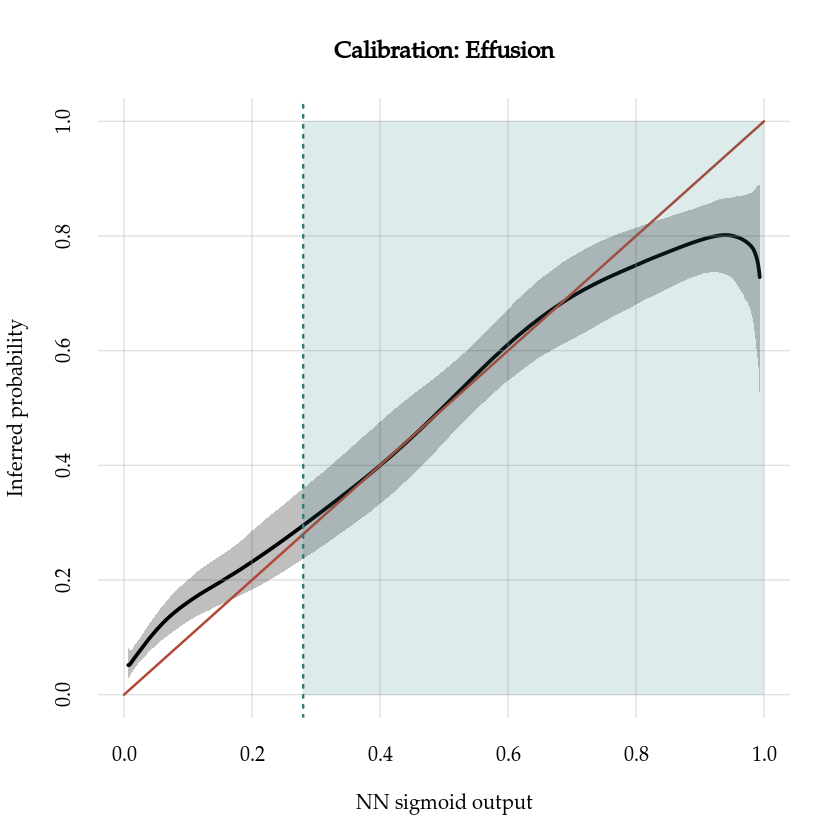

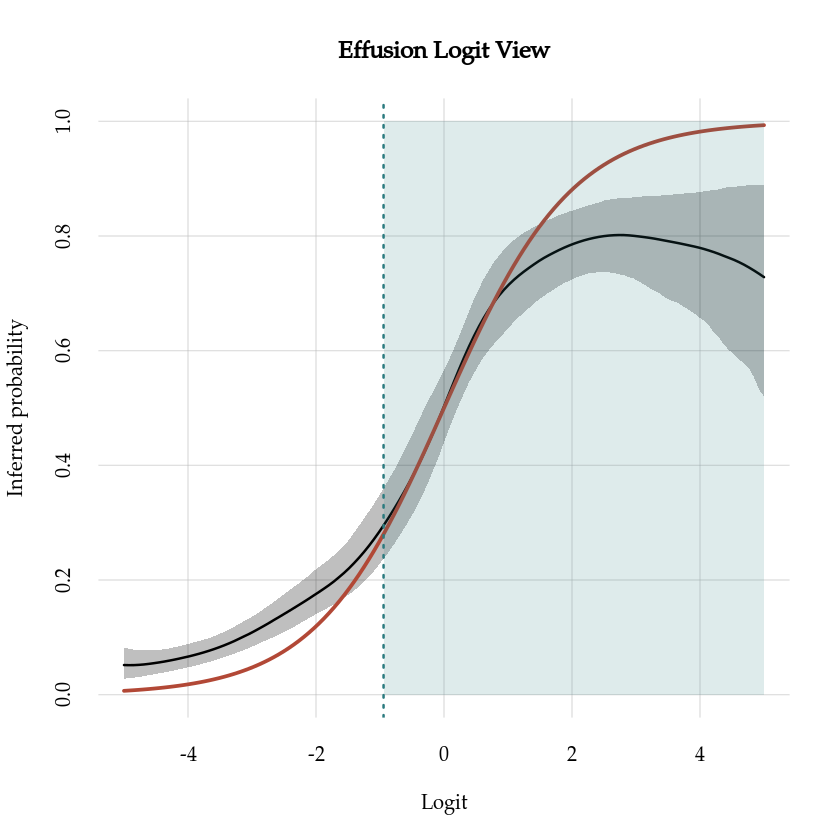

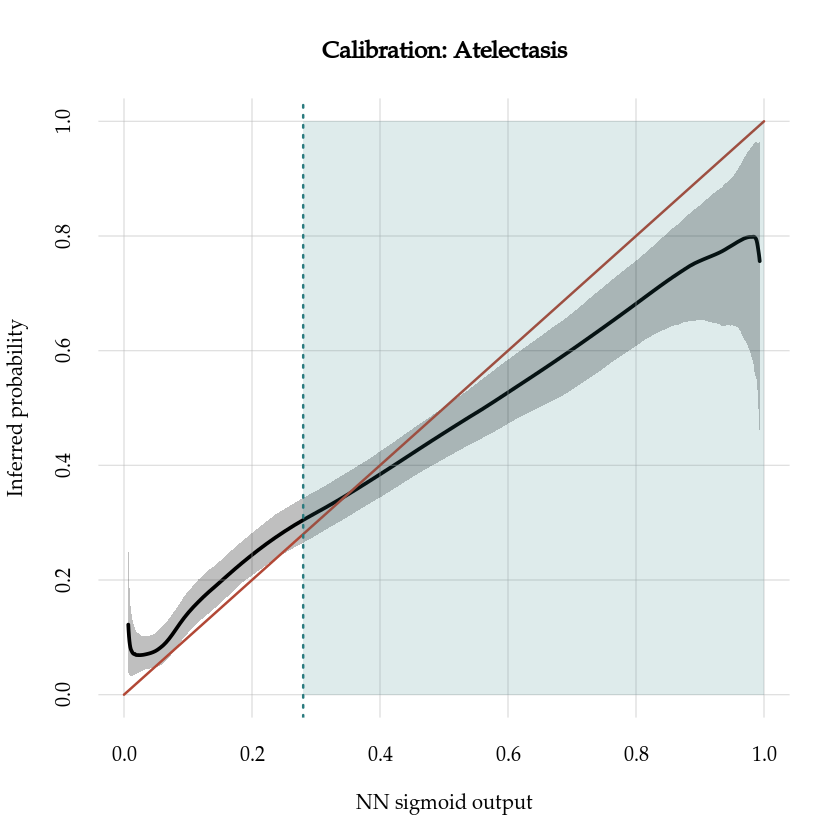

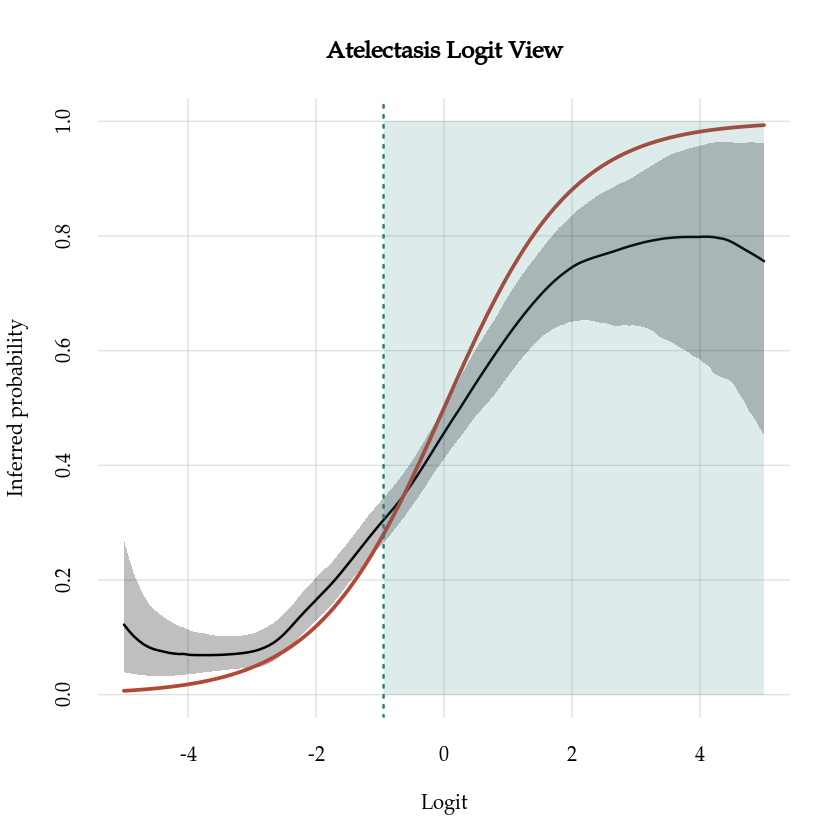

In [9]:
# -------------------------------
# Calibration Curves for Neural Net Outputs vs Inferred Probabilities
# -------------------------------

# Effusion Calibration Calculations
out_nn_effusion <- data.frame(LOGIT_EFFUSION = seq(-5, 5, length.out = 129))
prob_nn_effusion <- Pr(
  Y = data.frame(LABEL_EFFUSION = 1),
  X = out_nn_effusion,
  learnt = learnt_dir,
  parallel = parallel,
  quantiles = c(0.055, 0.945),
  nsamples = NULL
)

# Atelectasis Calibration Calculations
out_nn_atelectasis <- data.frame(LOGIT_ATELECTASIS = seq(-5, 5, length.out = 129))
prob_nn_atelectasis <- Pr(
  Y = data.frame(LABEL_ATELECTASIS = 1),
  X = out_nn_atelectasis,
  learnt = learnt_dir,
  parallel = parallel,
  quantiles = c(0.055, 0.945),
  nsamples = NULL
)

# Define helper function for calibration plots
plot_calibration <- function(out_nn, prob_nn, label_main, save_name, view = "sigmoid") {
  # Define color settings
  curve_color <- "#000000"
  sep_curve_color <- "#2b7b7f" # dark blueish
  ref_line_color <- "#b24836" # dark reddish
  shade_color <- adjustcolor("#2b7b7f", alpha.f = 0.15)

  threshold = 0.28

  # Function to perform actual plotting
  make_plot <- function() {
    par(family = "Palatino")
    if (view == "sigmoid") {
      flexiplot(
        x = plogis(out_nn[, 1]),
        y = c(prob_nn$values),
        xlab = "NN sigmoid output", ylab = "Inferred probability",
        ylim = 0:1, xlim = 0:1, lwd = 3, main = paste("Calibration:", label_main),
        col = curve_color
      )
      plotquantiles(x = plogis(out_nn[, 1]), y = prob_nn$quantiles[1, , ], add = TRUE)
      flexiplot(x = 0:1, y = 0:1, lty = 1, lwd = 2, col = ref_line_color, add = TRUE)
      polygon(x = c(threshold, 1, 1, threshold), y = c(0, 0, 1, 1), col = shade_color, border = NA)
      abline(v = threshold, col = sep_curve_color, lty = 3, lwd = 2)
    } else if (view == "logit") {
      plot(prob_nn, xlab = "Logit", ylab = "Inferred probability", ylim = 0:1, legend = FALSE, main = paste(label_main, "Logit View"))
      flexiplot(x = out_nn, y = plogis(out_nn[, 1]), lty = 1, col = ref_line_color, lwd = 3, add = TRUE)
      polygon(x = c(qlogis(threshold), 5, 5, qlogis(threshold)), y = c(0, 0, 1, 1), col = shade_color, border = NA)
      abline(v = qlogis(threshold), col = sep_curve_color, lty = 3, lwd = 2)
    }
  }

  # Save plot
  pdf2(save_name, path = output_dir)
  make_plot()
  dev.off()

  # Show plot inline
  make_plot()
}

# Generate and save 4 plots
plot_calibration(out_nn_effusion, prob_nn_effusion, "Effusion", "calib_eff_sigmoid", view = "sigmoid")
plot_calibration(out_nn_effusion, prob_nn_effusion, "Effusion", "calib_eff_logit", view = "logit")
plot_calibration(out_nn_atelectasis, prob_nn_atelectasis, "Atelectasis", "calib_ate_sigmoid", view = "sigmoid")
plot_calibration(out_nn_atelectasis, prob_nn_atelectasis, "Atelectasis", "calib_ate_logit", view = "logit")
